<h1 align="center">Física Computacional</h1>
<h1 align="center">Semestre 2025-4</h1>

<h2>Sergio A. Alcalá Corona</h2>
<h2>Rodrigo Vega Vilchis</h2>

---
### Alumno: Juan Alexis Hernández Hernández
---

<h1 align="center">Práctica 6. Metodos numéricos para Ecuaciones Diferenciales Parciales y simulacion de Procesos Aleatorios</h1>

In [100]:
import math as mt
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import scipy as sp

### **1. Ecuación de Poisson para un potencial electrostático**: La *ecuación de Poisson* gobierna el potencial electrostático en presencia de una densidad de carga $\rho$:

$$
\nabla^2 \phi = -\frac{\rho}{\varepsilon_0}
$$

### Aquí $\varepsilon_0$ es la permitividad del espacio vacío (asumiendo que estamos en el vacío). Ahora, considera el siguiente sistema que consiste en una caja cuadrada de $1$ metro de lado, con paredes conductoras conectadas a tierra a $0$ volts:

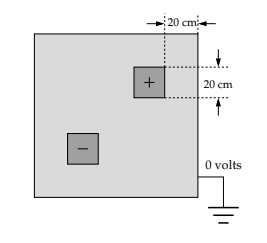

### Dentro de la caja hay dos cargas cuadradas de $20 \text{ cm}$ de lado, una positiva y otra negativa; colocadas a $20 \text{ cm}$ de las paredes de la caja. La densidad de carga de ambas es uniforme y tiene un valor de $\pm1\ \text{Cm}^{-2}$ respectivamente. Para simplificar, considere el sistema en dos dimensiones.

#### **(a)** Escribe un programa para calcular el potencial $\phi$ en una cuadrícula de puntos dentro de la caja usando el *método de relajación*.

In [ ]:
# Configuramos nuestra regiòn; 100 puntos = 100 cm
N = 100

phi_n = np.zeros((N,N))
phin_1 = np.copy(phi_n)

phi_n

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Definimos la fuente
e0 = 1
q1 = 1
q2 = -1

fuente = np.copy(phi_n)
fuente[20:40,N-40:N-20] = -q1/e0
fuente[N-40:N-20,20:40] = -q2/e0

fuente

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Programamos la solución a esta ecuación de Poisson a través del método de relajación
exactitud = 1e-6
error = 1.0

while error > exactitud:
    for i in range(N-1): # Lo dejamos hasta N-1 para dejar intacta la condición
        for j in range(N-1): # de frontera final
            if i==0 or j==0: # Igual, por la condición de frontera inicial, no debe cambiar
                continue
            else:
                phi_n[i,j] = -1/4*fuente[i,j] + 1/4*(phin_1[i+1,i] + phin_1[i-1,j] + phin_1[i,j+1] + phin_1[i,j-1])
                # Notemos que ese 1 = h ya que estamos ubicando los puntos/coordenadas de la matriz
    error = np.max(np.abs(phin_1 - phi_n))
    phin_1,phi_n = phi_n,phin_1

print(phi_n)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00 -2.08986053e-11 -6.86183614e-11 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -8.36582543e-12 -2.53996681e-11 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


#### **(b)** Realiza un *gráfico de densidad* del resultado.

#### Trabaja en unidades donde $\varepsilon_0 = 1$ y continúa la iteración hasta que tu solución para el potencial eléctrico cambie en menos de $10^{-6}\ \text{V}$ por paso en cada punto de la cuadrícula.

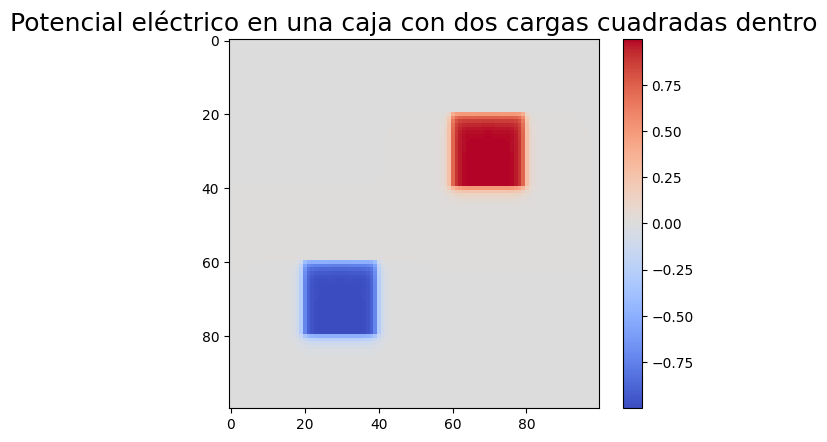

In [ ]:
pl.title("Potencial eléctrico en una caja con dos cargas cuadradas dentro",size=18)
colorbar = pl.imshow(phi_n,cmap='coolwarm')
pl.colorbar(colorbar)

### **2. Difusión térmica en la corteza terrestre**: Un ejemplo clásico de un problema de difusión con una condición de frontera variable en el tiempo es la *difusión de calor* hacia la corteza terrestre, a medida que la temperatura superficial varía con las estaciones. Supongamos que la temperatura media diaria en un punto particular de la superficie varía como:

$$
T_0(t) = A + B \sin\left(\frac{2\pi t}{\tau}\right),
$$

### donde $\tau = 365$ días, $A = 10^\circ \text{C}$ y $B = 12^\circ \text{C}$.

### A una profundidad de $20 \text{ m}$ bajo la superficie, casi toda la variación anual de temperatura se mantiene constante y la temperatura se mantiene, aproximadamente, en $11^\circ \text{C}$ (que es mayor que la temperatura superficial media de $10^\circ \text{C}$; la temperatura aumenta con la profundidad debido al calentamiento del núcleo caliente del planeta). La difusividad térmica de la corteza terrestre varía ligeramente de un lugar a otro, pero para nuestros propósitos la consideraremos constante con un valor $D = 0.1\ \text{m}^2\text{día}^{-1}$.

#### Escribe un programa, para calcular el perfil de temperatura de la corteza en función de la profundidad hasta $20 \text{ m}$ y el tiempo hasta $10$ años. Comienza con una temperatura en todas partes igual a $10^\circ \text{C}$, excepto en la superficie y el punto más profundo. Elige valores para el número de puntos de la cuadrícula y el intervalo de tiempo $h$. Luego, ejecuta el programa durante los primeros nueve años simulados para que se estabilice en el patrón que alcance. Para el décimo y último año, traza cuatro perfiles de temperatura tomados a intervalos de tres meses en un solo gráfico para ilustrar cómo cambia la temperatura en función de la profundidad y el tiempo.


Tenemos que resolver la ecuación del calor: $\frac{\partial\phi}{\partial t} = D\nabla²\phi$.

La parte de $\nabla²\phi$ ya sabemos cómo resolverla/expresarla, así que en realidad es solo una ecuación diferencial de primer orden respecto a $t$, que podemos resolverla con el método de Euler o Runge-Kutta.

También notemos que el problema está en términos de una profundidad recta, es decir, en una sola dimensión espacial, por lo tanto $\nabla²\phi = \frac{\partial²\phi}{\partial x²}$.

Método de Euler:

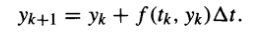

donde en nuestro caso queda de la siguiente manera:
$$\begin{align}
\phi_{n+1} &= \phi_n + \Delta t\,(D\nabla^2\phi_n) \\
&= \phi_n(x,t) + \Delta t\,(D \frac{\phi_n(x+h,t) + \phi_n(x-h,t) - 2\phi_n(x,t)}{h^2})
\end{align}$$

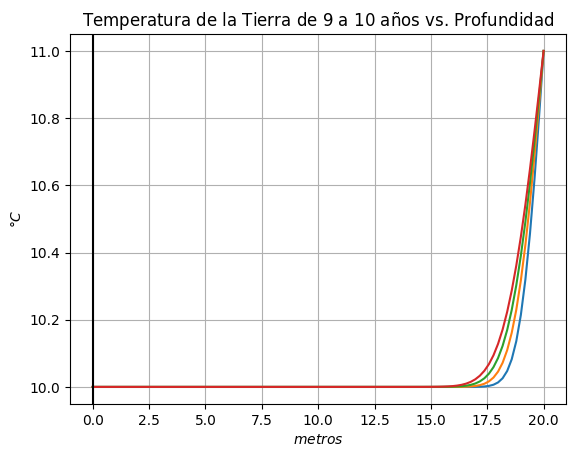

In [153]:
L = 20
D = 0.1*365 # Se hará por año en lugar de días para que no tarde mucho

N = 100 # Número de separación espacial
h = L/N
dt = 0.0001

# ESTABILIZAMOS EN 9 AÑOS
for treal in range(9):
  t = 0.0
  tf = treal + h/1000 # Límite de tiempo para el método de Euler

  T = np.zeros(N) # Para guardar las temperaturas
  T[0] = 10 + 12*np.sin(2*np.pi*treal/1) # Condición de frontera superficie
  T[N-1] = 11 # Condición de frontera profundidad
  T[1:N-1] = 10 # Temperatura en el resto de la corteza
  Tn = np.copy(T)

  # Método de Euler
  while t < tf:
    for i in range(1,N-1): # No pasamos por el 0 ni por N ya que son
                           # las condiciones de frontera y ahí el valor no cambia
      Tn[i] = T[i] + (dt*D/(h**2))*(T[i+1]+T[i-1]-2*T[i])
    T,Tn = Tn,T
    t = t + h

# YA ESTABILIZADO, HACEMOS 4 PERIODOS DE 3 MESES
for treal in [9.25,9.5,9.75,10]:
  t = 0.0
  tf = treal + h/1000

  while t < tf:
    for i in range(1,N-1): # No pasamos por el 0 ni por N ya que son
                           # las condiciones de frontera y ahí el valor no cambia
      Tn[i] = T[i] + dt*(D/(h**2)*(T[i+1]+T[i-1]-2*T[i]))
    T,Tn = Tn,T
    t = t + h
  # Esos N = 100 cachos los ponemos a un valor correspondiente entre 0 y 20
  # para un mejor entendimiento de la gráfica
  I = np.linspace(0,20,100)
  pl.plot(I,T)

pl.title(r'Temperatura de la Tierra de $9$ a $10$ años vs. Profundidad')
pl.xlabel(r'$metros$')
pl.ylabel(r'$°C$')
pl.axvline(x=0,c='k')
pl.grid()

### **3. Solución FTCS (***forward-time centered-space***) de la ecuación de onda**: Considera una cuerda de piano de longitud $L$, inicialmente en reposo. En el instante $t = 0$, el martillo del piano golpea la cuerda a una distancia $d$ del extremo de la cuerda:

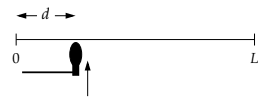

### La cuerda vibra al ser golpeada, excepto en los extremos $x = 0$ y $x = L$, donde se mantiene fija.

#### Escribe un programa que utilice el **método** de ***espacio centrado en tiempo hacia adelante*** (*forward-time centered-space*) **FTCS**, para resolver el **conjunto completo** de ecuaciones (diferenciales ordinarias) simultáneas de primer orden, para el caso $v = 100~\text{m/s}$, con la condición inicial de que $\phi(x) = 0$ en todas partes excepto cuando la velocidad $\psi(x) = \dot{\phi}$ es distinta de cero, i.e.:

$$
\psi(x) = C \cdot \frac{x(L - x)}{L^2} \cdot \exp\left[-\frac{(x - d)^2}{2\sigma^2}\right],
$$

#### donde $L = 1 \text{ m}$, $d = 10 \text{ cm}$, $C = 1  \text{ m/s}$ y $\sigma = 0.3 \text{ m}$. Elige un valor razonable para $h$ (por ejemplo $h = 10^{-6} \text{ s}$).

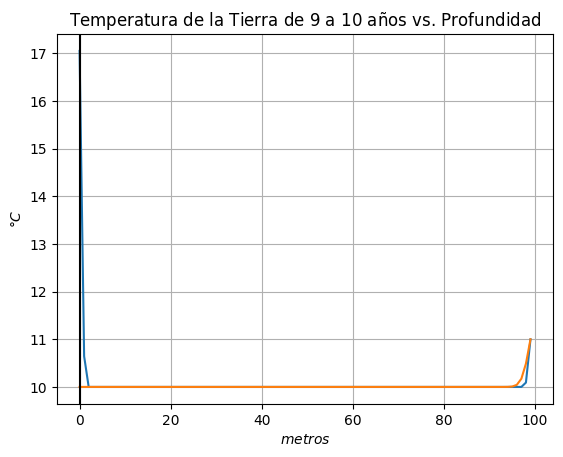

In [152]:
L = 1
v = 100
d = 0.1
c = 1
sigma = 0.3

N = 100 # Número de separación espacial
h = L/N
dt = 0.0001

for treal in [0.1,2]:
  t = 0.0
  tf = treal + h/1000 # Límite de tiempo para el método de Euler

  T = np.zeros(N) # Para guardar las temperaturas
  T[0] = 10 + 12*np.sin(2*np.pi*treal/1) # Condición de frontera superficie
  T[N-1] = 11 # Condición de frontera profundidad
  T[1:N-1] = 10 # Temperatura en el resto de la corteza
  Tn = np.copy(T)

  # Método de Euler
  while t < tf:
    for i in range(1,N-1): # No pasamos por el 0 ni por N ya que son
                           # las condiciones de frontera y ahí el valor no cambia
      Tn[i] = T[i] + (dt*D/(h**2))*(T[i+1]+T[i-1]-2*T[i])
    T,Tn = Tn,T
    t = t + h
  pl.plot(T)

pl.title(r'Temperatura de la Tierra de $9$ a $10$ años vs. Profundidad')
pl.xlabel(r'$metros$')
pl.ylabel(r'$°C$')
pl.axvline(x=0,c='k')
pl.grid()

In [203]:
L = 1
v = 100
d = 0.1
c = 1
sigma = 0.3

N = 200 # Número de separación espacial
h = L/N
dt = 0.0001

for treal in [0.1]:
  t = 0.0
  tf = treal + h/1000 # Límite de tiempo para el método de Euler

  phi = np.zeros(N)
  # Condición inicial (phi no tiene así que la dejamos en 0)
  x = np.linspace(0, L, N)
  psi = c*x*(L-x)/L**2*np.exp(-(x-d)**2/(2*sigma**2))

  # Condiciones de frontera
  phi[0] = 0
  phi[N-1] = 0

  # Condiciones de frontera (psi = 0 a no ser que phi se mueva)
  psi[0] = 0
  psi[N-1] = 0

  phin = np.copy(phi)
  psin = np.copy(psi)

  # Método de Euler
  while t < tf:
    for i in range(1,N-1): # No pasamos por el 0 ni por N ya que son
                           # las condiciones de frontera y ahí el valor no cambia
      phin[i] = phi[i] + dt*(psi[i])
      psin[i] = psi[i] + dt*((v**2)/(h**2)*(phi[i+1]+phi[i-1]-2*phi[i]))
    phi,phin = phin,phi
    psi,psin = psin,psi
    t = t + h
  # Esos N = 100 cachos los ponemos a un valor correspondiente entre 0 y 20
  # para un mejor entendimiento de la gráfica
  I = np.linspace(0,1,N)

pl.figure(size=(10,10))
pl.plot(I,phi)
# pl.figure(size=(10,10))
pl.plot(I,phi)
pl.title(r'Temperatura de la Tierra de $9$ a $10$ años vs. Profundidad')
pl.xlabel(r'$metros$')
pl.ylabel(r'$°C$')
pl.axvline(x=0,c='k')
pl.grid()

# pl.figure(size=(10,10))
# pl.plot(I,psi)

AttributeError: Figure.set() got an unexpected keyword argument 'size'

### **4. Lanzando dados**


#### **(a)** Escribe un programa que genere e imprima dos números aleatorios entre $1$ y $6$ para simular el lanzamiento de dos dados.

#### **(b)** Modifica tu programa para simular el lanzamiento de dos dados un millón de veces y cuenta el número de veces que obtienes un doble seis. Divide entre un millón para obtener la *fracción* de veces que obtienes un doble seis. Deberías obtener un resultado cercano a: $\frac{1}{36}$.

### **5. Movimiento browniano y caminatas aleatorias**: El *movimiento browniano* es el movimiento de una partícula (por ejemplo de humo o polvo) en un gas, al chocar aleatoriamente con las moléculas del propio gas.

### En una simulación computacional en dos dimensiones (2D) se puede considerar que dicha partícula está confinada en una cuadrícula (o red cuadrada) de $L \times L$ cuadrados de lado, de modo que su posición puede representarse mediante dos enteros $x$, $y$ y comienza en el centro de la cuadrícula. Así, en cada paso de la simulación, se elige una dirección aleatoria (arriba, abajo, izquierda o derecha) y la partícula se mueve un paso en esa dirección. Este proceso se denomina *caminata aleatoria*. Realiza una simulación computacional del movimiento browniano, como se indica a continuación.

### Para comenzar, considera un caminante aleatorio en **una dimensión** (1D), el cual da un paso (de longitud $l$) hacia la derecha con probabilidad $p$ o uno a la izquierda con probabilidad $q = 1 - p$.



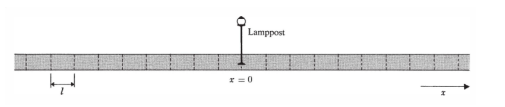

#### **(a)** Escribe un programa que simule una *caminata aleatoria* de $N$ pasos y haz una gráfica de las posiciones de la caminata vs el tiempo. Asimismo, grafica un histograma de la frecuencia de dichas posiciones. Puedes considerar $l = 1$, para simplificar las cosas.

#### **(b)** Ahora, convierte tu programa del ejercicio anterior en una función y úsala para generar 100 caminatas aleatorias. Haz una sola gráfica de las posiciones de todas las caminatas vs el tiempo $t$. Asimismo, grafica un único histograma de la frecuencia de las posiciones de todas las caminatas. **¿Qué es lo que observas?, ¿cuál es la diferencia con lo que obtuviste en el ejercicio anterior?**

#### **(c)** Finalmente, generaliza tu programa para simular una (o varias) caminatas aleatorias en 2D y 3D, y úsalas para graficar las posiciones $(x, y)$ o $(x, y, z)$ de una o varias caminatas.

### ** **Problema opcional: Área de un círculo unitario (2 puntos extra)**: Estima el área de un círculo de radio unitario utilizando el método de Monte Carlo.


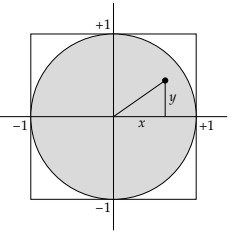

### El área del círculo, el área sombreada arriba, viene dada por la integral:

$$
I = \iint_{-1}^{+1} f(x, y) \, dx \, dy,
$$

### donde $f(x,y) = 1$ en todo el interior del círculo y cero en el exterior. En otras palabras,

$$f(x, y) = \begin{cases} 1 & \text{si } x^2 + y^2 \leq 1, \\ 0 & \text{en caso contrario}. \end{cases}$$

### Así, si no conociéramos el área del círculo, podríamos calcularla mediante integración de Monte Carlo. Habría que generar un conjunto de $N$ puntos aleatorios $(x, y)$, donde tanto $x$ como $y$ están en el rango de $-1$ a $1$. Con lo que la aproximación quedaría como:

$$
I \approx \frac{4}{N} \sum_{i=1}^{N} f(x_i, y_i)
$$